In [15]:
import json
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn import tree

import matplotlib.pyplot as plt

In [16]:
import json
import pandas as pd

ruta = "/home/zikocaklos/proyectos_mineria/nasa_neo_etl/data/raw/neo_raw.json"

with open(ruta, "r", encoding="utf-8") as file:
    data = json.load(file)

df = pd.DataFrame(data)

df.head()

,name,absolute_magnitude,diameter_min,diameter_max,diameter_avg,is_hazardous,velocity_kph,miss_distance_km
0,(2014 CE13),24.09,0.040416,0.090373,0.065395,False,60500.303027,3.434808e+06
1,(2016 CO246),25.80,0.018389,0.041119,0.029754,False,40223.154310,3.303107e+07
2,(2016 SZ1),26.30,0.014607,0.032662,0.023634,False,50344.139018,2.156626e+07
3,(2018 FD),24.27,0.037201,0.083184,0.060193,False,85167.239921,7.407618e+07
4,(2019 BV1),28.80,0.004619,0.010329,0.007474,False,99997.184389,6.926015e+07


In [17]:
df.columns

Index(['name', 'absolute_magnitude', 'diameter_min', 'diameter_max',
       'diameter_avg', 'is_hazardous', 'velocity_kph', 'miss_distance_km'],
      dtype='object')

In [18]:
df.isnull().sum()

name                  0
absolute_magnitude    0
diameter_min          0
diameter_max          0
diameter_avg          0
is_hazardous          0
velocity_kph          0
miss_distance_km      0
dtype: int64

In [19]:
X = df[[
    "diameter_min",
    "diameter_max"
]]

y = df["diameter_avg"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
modelo = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

modelo.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [22]:
y_pred = modelo.predict(X_test)

y_pred[:10]

array([0.01532244, 0.22427703, 0.03080453, 0.01532244, 0.37935878,
       0.13511901, 0.10807182, 0.22427703, 0.19338556, 0.47291092])

In [23]:
r2 = r2_score(y_test, y_pred)

print("R²:", r2)

R²: 0.9963446110953321


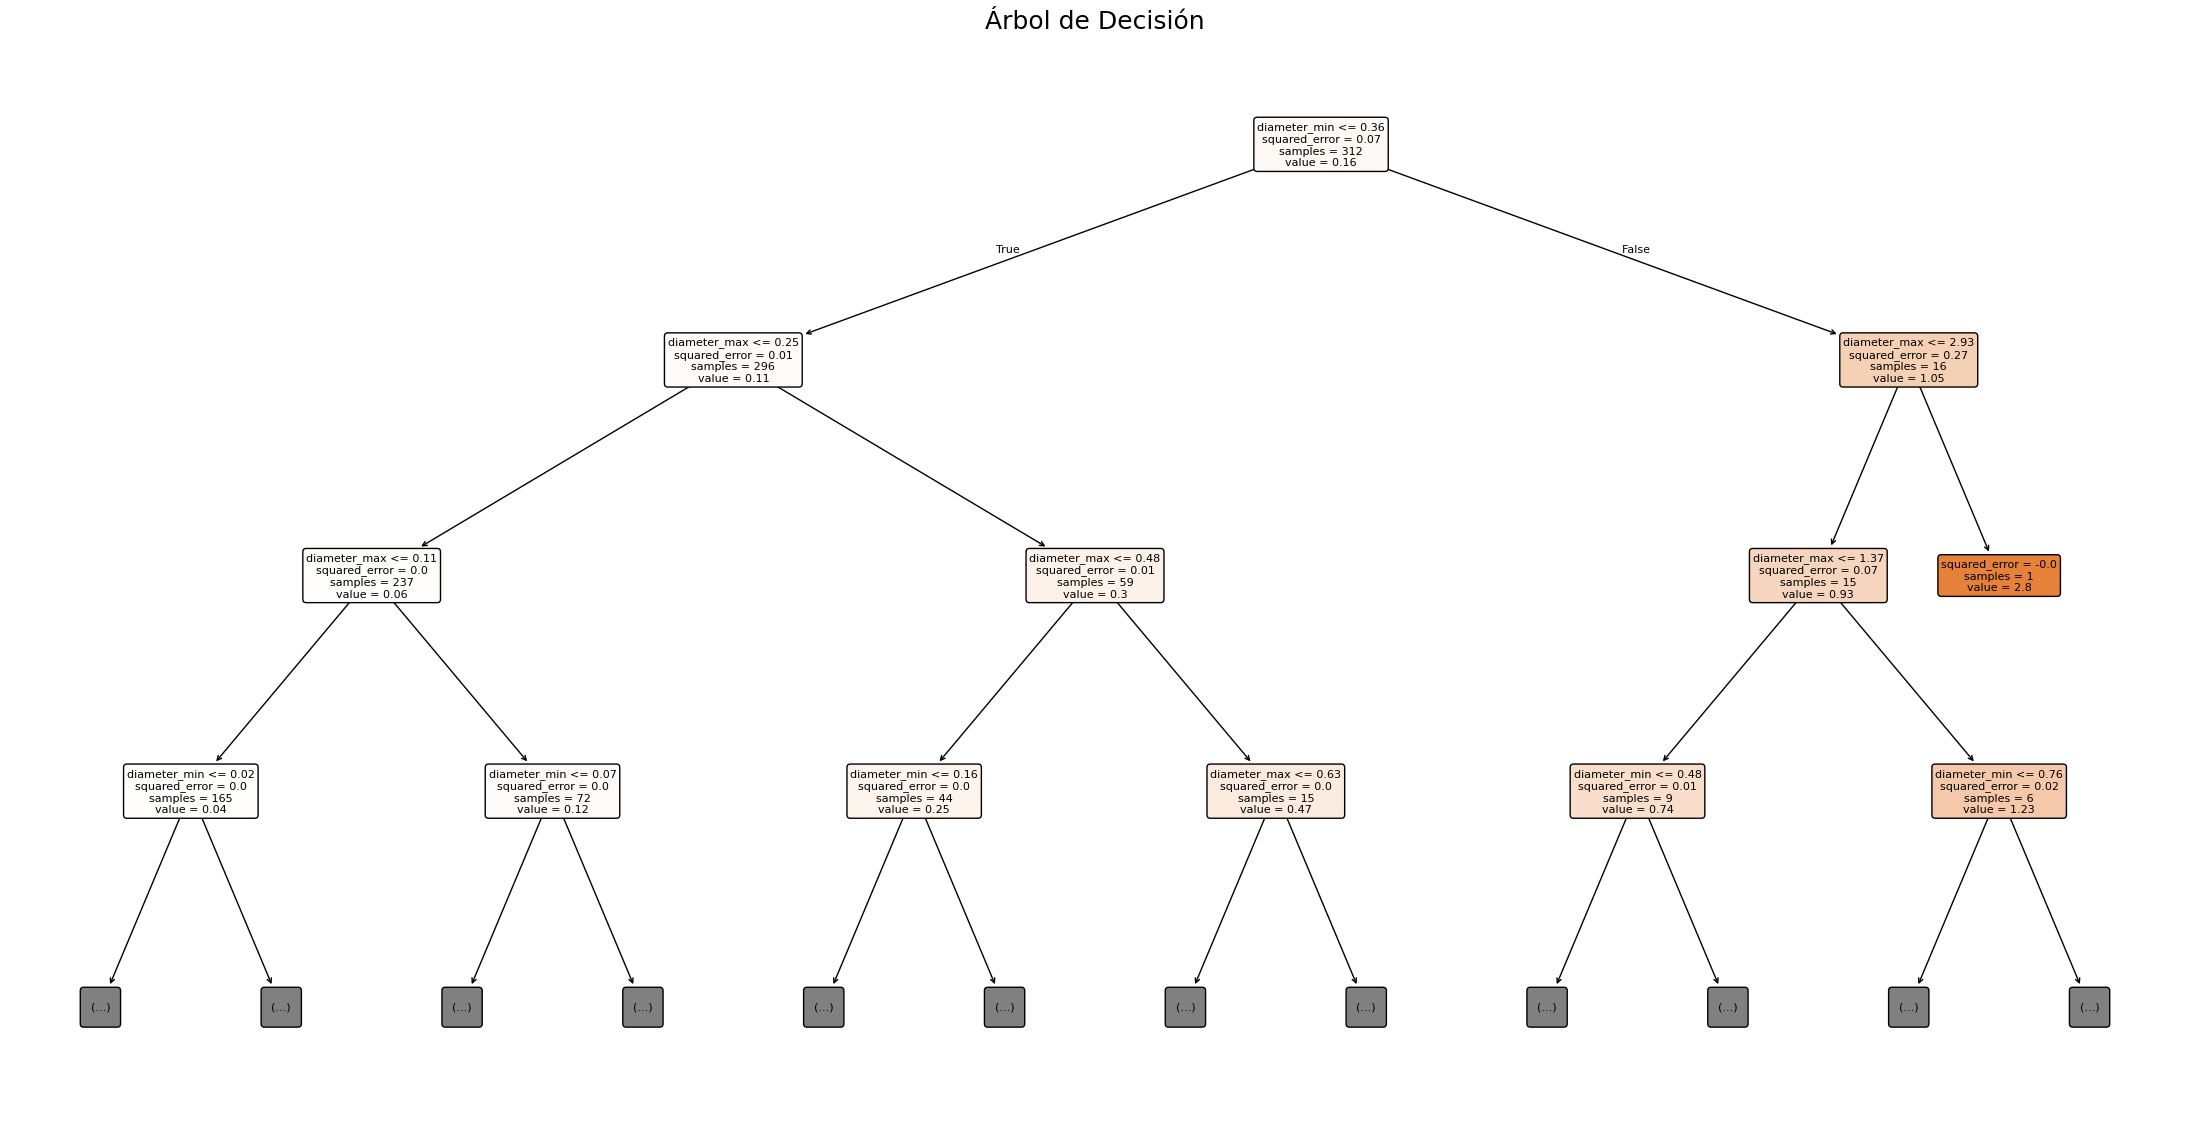

In [24]:
plt.figure(figsize=(28,14))

tree.plot_tree(
    modelo,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3,
    precision=2
)

plt.title("Árbol de Decisión", fontsize=18)

plt.show()

In [25]:
comparacion = pd.DataFrame({
    "Real": y_test.values,
    "Prediccion": y_pred
})

comparacion.head(20)

,Real,Prediccion
0,0.011845,0.015322
1,0.229902,0.224277
2,0.038330,0.030805
3,0.015615,0.015322
4,0.352811,0.379359
5,0.131082,0.135119
6,0.118452,0.108072
7,0.209673,0.224277
8,0.205846,0.193386
9,0.502971,0.472911


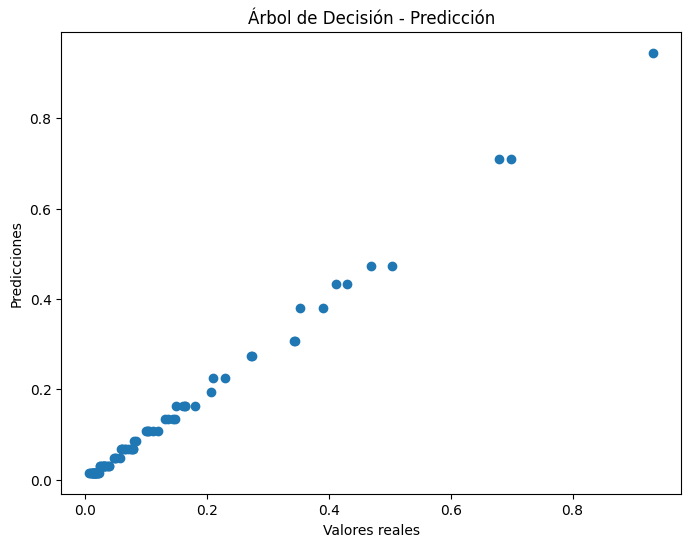

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")

plt.title("Árbol de Decisión - Predicción")

plt.show()